In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Lasso


from collections import namedtuple
Dataset = namedtuple('Dataset', ['X_train', 'X_test', 'y_train', 'y_test'])
Params = namedtuple('Params', ['min_samples_leaf', 'max_features', 'max_depth', 'oob_score'])
Data = namedtuple('Data', ['X','y'])
parameters = Params(3, 0.3, 25, False)


import sys
sys.path.append('../library')

import classification_rf
from importlib import reload
reload(classification_rf)

import rf_wrapper_functions as rfwrap

np.random.seed(24)

In [3]:
df = pd.read_csv("../Input_Data/TGCA Cancer Classification/TGCA_Processed.csv")

In [5]:
# Drop specified columns and convert to NumPy array
X = df.drop(columns=["bcr_patient_barcode", "OS","type"]).to_numpy()
y = df["OS"].to_numpy().astype(int)

from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)

X_train, X_test, y_train, y_test = rfwrap.split_by_source(X, y, test_size=0.2, random_state=24)
dataset = Dataset(X_train, X_test, y_train, y_test)
data = Data(X,y)

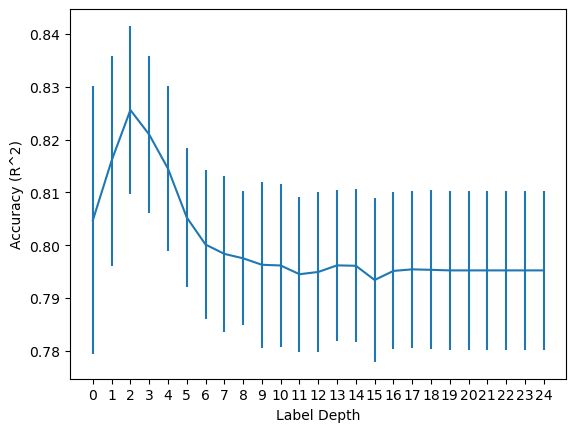

In [6]:
accuracy_score, rf, source_score, source_size, X_tests, y_tests = rfwrap.errorbars_kfold_data(
    n_folds = 10,
    n_estimators=300, 
    depth=25,
    data = data,
    parameters=parameters, 
    metric = "auc", 
    plot=True)

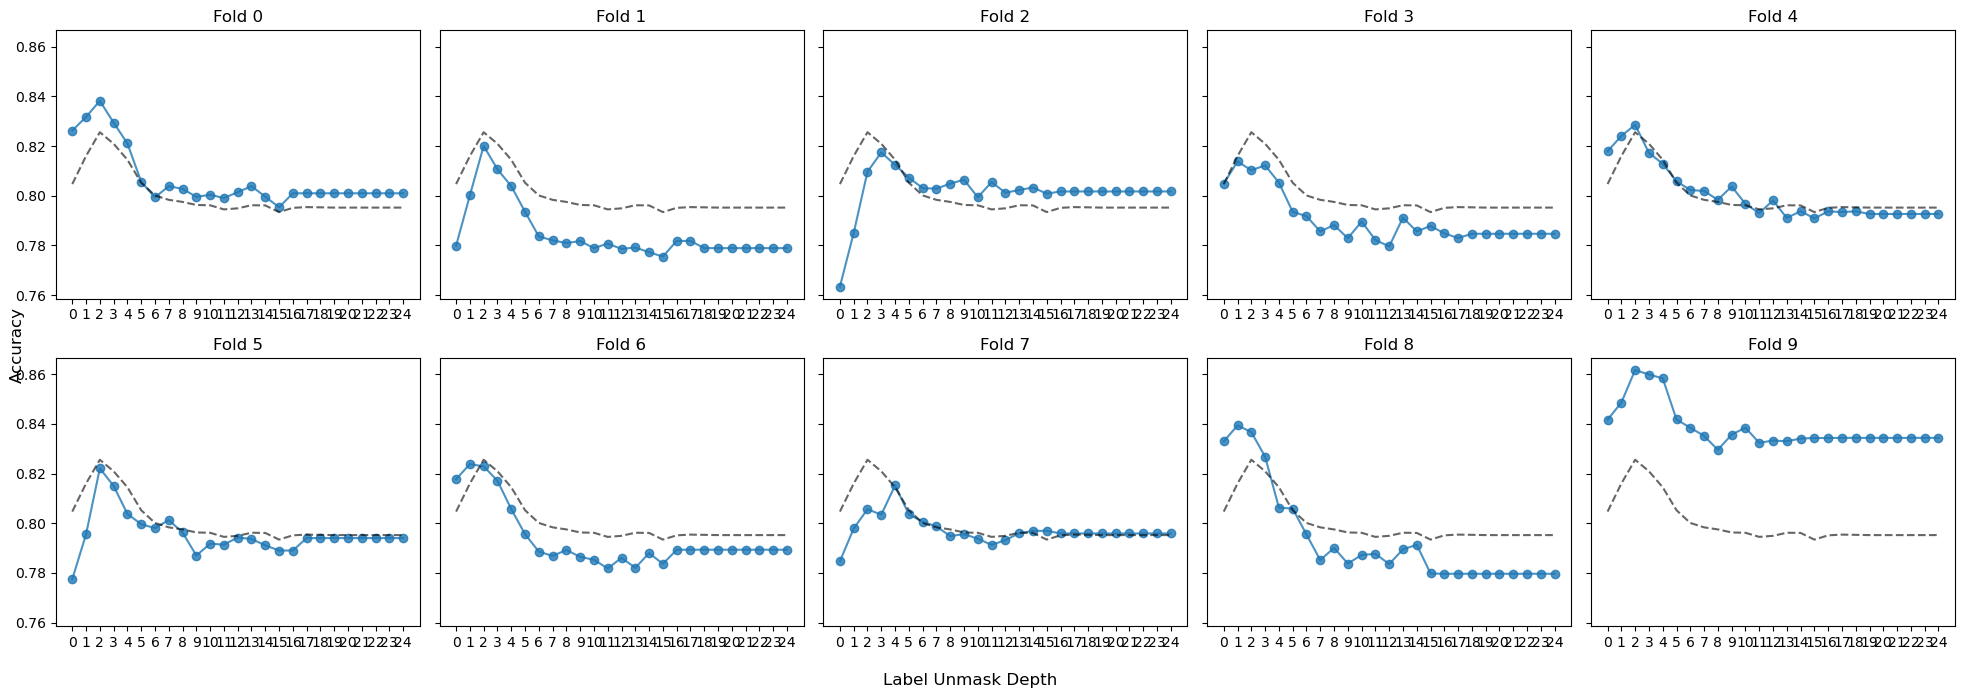

In [8]:
rfwrap.plot_forests_by_fold(accuracy_score, dataset, parameters, depth_type = "depth")